In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [5]:
# Load the dataset
df = pd.read_csv('mushroom.csv')

# Fundamental data exploration
print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print("\nStatistical Summary:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 

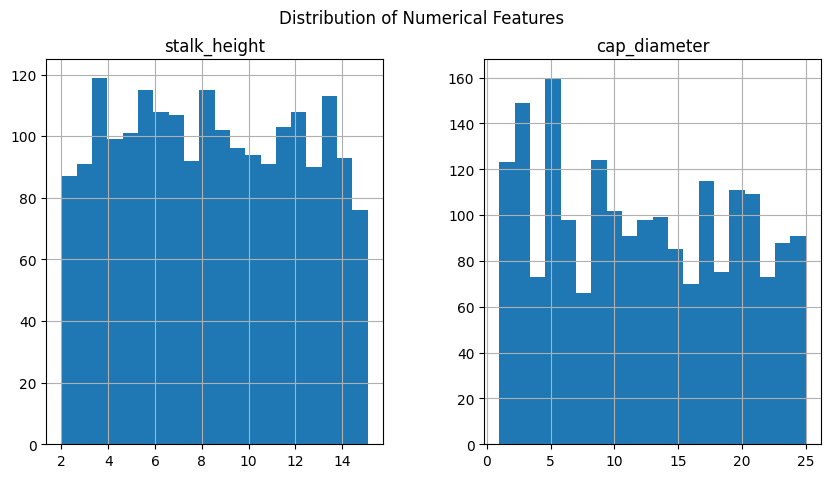

In [6]:
# Feature distributions for numerical columns
numerical_cols = ['stalk_height', 'cap_diameter']
df[numerical_cols].hist(bins=20, figsize=(10, 5))
plt.suptitle("Distribution of Numerical Features")
plt.show()

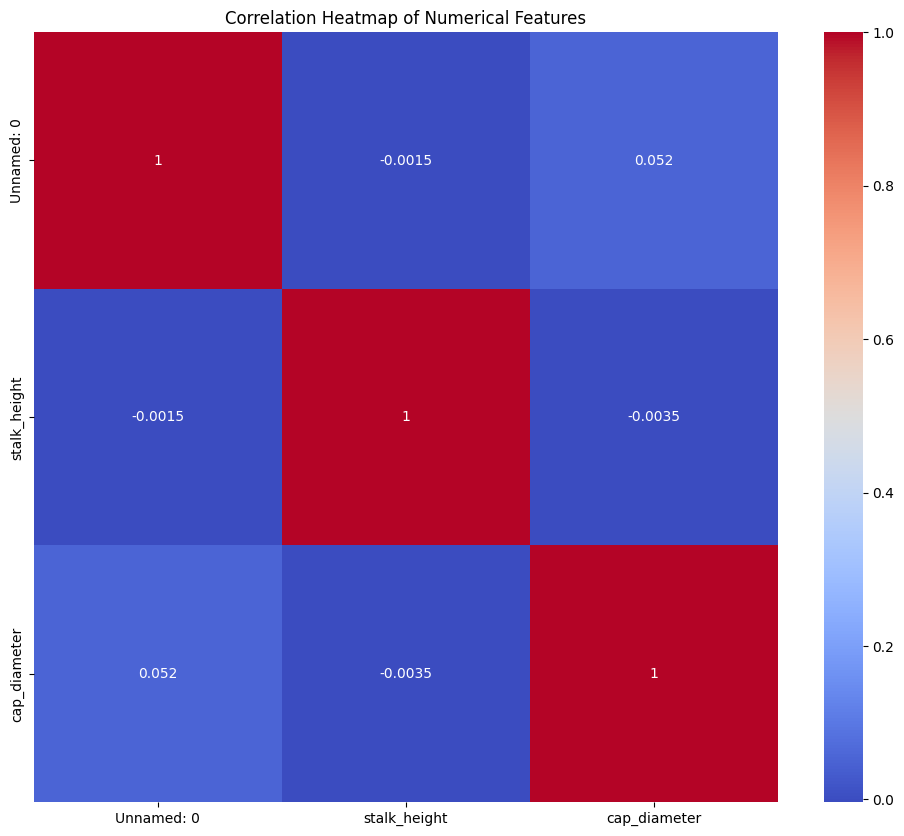

In [7]:
# Investigate feature correlations (using encoded values for heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

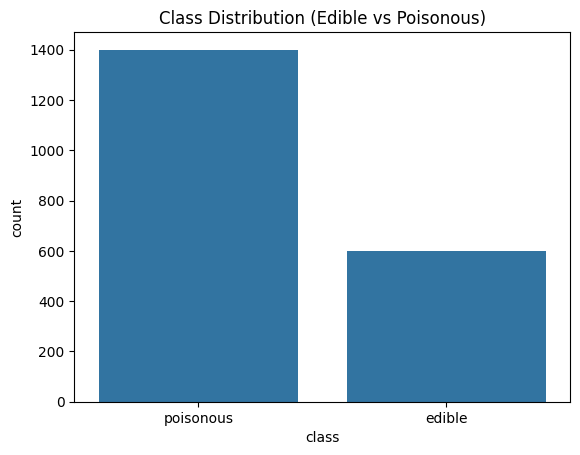

In [8]:
# Drop unnecessary column
df = df.drop(columns=['Unnamed: 0'])

sns.countplot(x='class', data=df)
plt.title("Class Distribution (Edible vs Poisonous)")
plt.show()

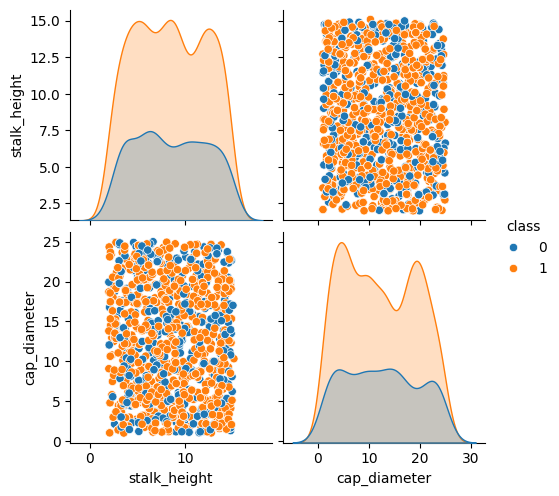

In [9]:
# Encode categorical variables
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Plotting a subset of features for clarity
sns.pairplot(df[['stalk_height', 'cap_diameter', 'class']], hue='class')
plt.show()

In [10]:
# Split the dataset
X = df.drop('class', axis=1)
y = df['class']

In [11]:
# Feature scaling (Crucial for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [12]:

# Implement basic SVM classifier (RBF kernel by default)
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

# Evaluate model performance
y_pred = svm_model.predict(X_test)
print("Basic SVM Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Basic SVM Accuracy: 0.785

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.38      0.54       133
           1       0.76      0.99      0.86       267

    accuracy                           0.79       400
   macro avg       0.84      0.68      0.70       400
weighted avg       0.82      0.79      0.75       400



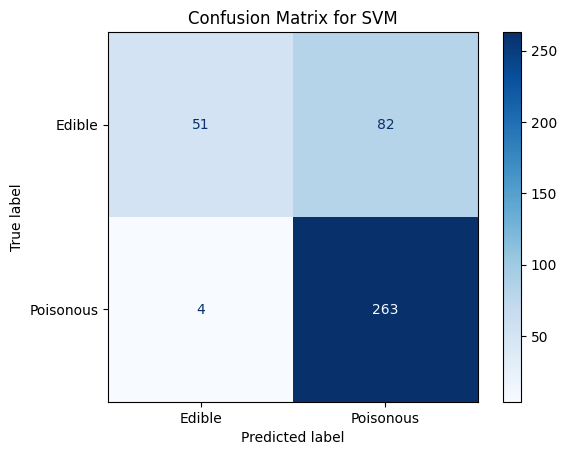

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Edible', 'Poisonous'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for SVM")
plt.show()